In [64]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from scipy import stats

import os
from pathlib import Path
import sys
# Set sys path
sys.path.append(str(Path(os.getcwd()).parent))

# Set filpaths for data and figures
notebook_dir = os.getcwd()
file_path = Path(notebook_dir).parent / 'data' 

In [66]:
plt.rcParams['pdf.fonttype'] = 42  # Use Type 3 (PostScript) fonts
plt.rcParams['ps.fonttype'] = 42

In [67]:
file_path

PosixPath('/Users/jbmr/Notebooks/data_viz/data')

In [68]:
# load data
d_plasma = pd.read_csv(file_path / 'Scivias_PCAN_proteins.tsv', sep='\t', index_col=0)

In [69]:
# load data
d_urine = pd.read_csv(file_path / 'Scivias_urine_proteins.tsv', sep='\t', index_col=0)

In [70]:
d_meta_plasma = pd.read_csv(file_path / 'Scivias_plasma_metadata.tsv', sep='\t', index_col=0)

In [71]:
d_meta_urine = pd.read_csv(file_path / 'Scivias_urine_metadata.tsv', sep='\t', index_col=0)

# data structure
proteomics data with proteins as columns and samples as rows

In [72]:
d_plasma

,A0A024R1R8;Q9Y2S6,A0A075B6H7,A0A075B6I0,A0A075B6I9,A0A075B6J1,A0A075B6J9,A0A075B6K0,A0A075B6K2,A0A075B6K4,A0A075B6K5,...,Q9Y646,Q9Y653-5,Q9Y6C2,Q9Y6F6-3;Q9Y6F6-5,Q9Y6I9,Q9Y6M7-12;Q9Y6M7-8,Q9Y6R7,Q9Y6W3,Q9Y6Y9,Q9Y6Z7
P01_A01,NaN,4.458457,5.312050,4.578302,3.181054,4.198316,3.983582,2.837581,5.277082,5.144518,...,3.642569,3.600890,NaN,NaN,NaN,4.446380,4.541751,4.063754,3.215638,4.340569
P01_A02,4.163072,4.208619,5.558028,4.381431,NaN,4.581916,NaN,NaN,5.293024,5.225818,...,3.817016,3.669798,3.066766,NaN,NaN,NaN,4.285499,3.939671,3.349025,4.335329
P01_A03,4.000577,4.625975,5.656026,4.702237,NaN,4.900476,4.541595,NaN,5.866296,5.829046,...,4.241330,3.526185,3.177943,NaN,NaN,3.924085,4.687596,3.667681,3.253721,3.854947
P01_A04,4.209260,4.355001,4.919161,4.313156,NaN,4.330560,3.925775,3.097531,4.937413,5.542439,...,3.550006,3.529819,NaN,NaN,NaN,4.320599,4.931857,3.872847,3.298121,4.341389
P01_A05,4.078479,3.721408,4.451332,NaN,NaN,4.220370,NaN,NaN,4.691826,5.000551,...,3.916710,3.745076,3.192264,NaN,NaN,NaN,NaN,3.956799,3.415931,4.279977
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P14_D12,4.384697,4.224222,5.017330,3.729440,NaN,4.474349,NaN,NaN,4.833414,4.963101,...,3.574559,3.842268,3.463251,3.373048,NaN,NaN,4.296387,4.067881,NaN,4.233757
P14_E12,4.410222,4.159790,4.955922,3.772259,NaN,4.454030,NaN,NaN,4.799068,4.923599,...,3.297542,4.016837,3.259637,2.910340,2.618121,NaN,4.310823,4.449630,NaN,4.227035
P14_F12,4.315710,3.941148,5.143080,4.283792,NaN,4.543706,NaN,NaN,4.816320,4.953364,...,3.518239,3.904196,NaN,3.418861,NaN,NaN,NaN,4.258149,NaN,4.258141
P14_G12,4.325821,4.225439,5.050990,4.178355,NaN,4.582854,NaN,NaN,4.862567,4.996329,...,3.910363,3.754565,NaN,3.151367,2.764024,NaN,4.169383,4.128629,NaN,4.300776


In [73]:
d_urine

,A0A075B6H7,A0A075B6H9,A0A075B6H9;A0A075B6K6;A0A0B4J1Y8,A0A075B6I0,A0A075B6I7;A0A087WSX0;A0A0G2JS06,A0A075B6I9,A0A075B6J9,A0A075B6K0;A0A075B6K4,A0A075B6K4,A0A075B6K5,...,Q9Y6I3;Q9Y6I3-1;Q9Y6I3-3,Q9Y6N5,Q9Y6R1;Q9Y6R1-2;Q9Y6R1-3;Q9Y6R1-4;Q9Y6R1-5,Q9Y6R7,Q9Y6U3;Q9Y6U3-2,Q9Y6U3;Q9Y6U3-2;Q9Y6U3-3,Q9Y6U3;Q9Y6U3-3,Q9Y6W3,Q9Y6X5,Q9Y6Z7
P02_E01,3.795799,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,3.121643,3.721806,NaN,NaN,3.038426,4.933575,NaN,NaN
P01_E01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P02_E02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.459232,3.175787,NaN,NaN,4.674750,NaN,NaN
P01_E02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
P02_E03,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.050161,NaN,3.673265,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
P12_H05,NaN,NaN,NaN,3.971022,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.114033,NaN,3.555140,NaN,4.632341,NaN,NaN
P11_H06,3.904665,NaN,NaN,3.421413,NaN,3.121036,NaN,NaN,3.292871,2.943095,...,NaN,NaN,NaN,4.164992,3.146121,3.103831,3.233597,4.524820,3.503964,3.578244
P12_H06,4.207885,NaN,NaN,3.856161,NaN,3.824288,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,4.216801,NaN,3.211626,3.362539,4.620201,3.294917,3.663638
P11_H07,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.997606,NaN,NaN


In [74]:
d_meta_plasma

,sct_description
index_PCAN,
P02_G09,Crohn's disease (disorder)
P02_D09,Conjunctivitis (disorder)
P02_D09,Periodic fever and aphthous stomatitis with ph...
P04_B08,Chronic nonbacterial osteomyelitis/chronic rec...
P04_B08,Crohn's disease (disorder)
...,...
P12_C07,Recurrent infectious disease (disorder)
P12_C08,Celiac disease (disorder)
P12_C09,Functional abdominal pain syndrome (disorder)


In [75]:
d_meta_urine

,sct_description
index_urine,
P02_C02,Crohn's disease (disorder)
P02_G09,Crohn's disease (disorder)
P02_D09,Conjunctivitis (disorder)
P02_D09,Periodic fever and aphthous stomatitis with ph...
P04_B08,Chronic nonbacterial osteomyelitis/chronic rec...
...,...
P12_B03,Well child (finding)
P11_E07,Protein C deficiency disease (disorder)
P09_C08,Thrombosis (disorder)


In [76]:
d_merge_plasma = pd.merge(d_meta_plasma, d_plasma, left_index=True, right_index=True)

In [77]:
d_merge_urine = pd.merge(d_meta_urine, d_urine, left_index=True, right_index=True)

In [78]:
d_plasma.columns

Index(['A0A024R1R8;Q9Y2S6', 'A0A075B6H7', 'A0A075B6I0', 'A0A075B6I9',
       'A0A075B6J1', 'A0A075B6J9', 'A0A075B6K0', 'A0A075B6K2', 'A0A075B6K4',
       'A0A075B6K5',
       ...
       'Q9Y646', 'Q9Y653-5', 'Q9Y6C2', 'Q9Y6F6-3;Q9Y6F6-5', 'Q9Y6I9',
       'Q9Y6M7-12;Q9Y6M7-8', 'Q9Y6R7', 'Q9Y6W3', 'Q9Y6Y9', 'Q9Y6Z7'],
      dtype='object', length=1958)

In [79]:
d_urine.columns

Index(['A0A075B6H7', 'A0A075B6H9', 'A0A075B6H9;A0A075B6K6;A0A0B4J1Y8',
       'A0A075B6I0', 'A0A075B6I7;A0A087WSX0;A0A0G2JS06', 'A0A075B6I9',
       'A0A075B6J9', 'A0A075B6K0;A0A075B6K4', 'A0A075B6K4', 'A0A075B6K5',
       ...
       'Q9Y6I3;Q9Y6I3-1;Q9Y6I3-3', 'Q9Y6N5',
       'Q9Y6R1;Q9Y6R1-2;Q9Y6R1-3;Q9Y6R1-4;Q9Y6R1-5', 'Q9Y6R7',
       'Q9Y6U3;Q9Y6U3-2', 'Q9Y6U3;Q9Y6U3-2;Q9Y6U3-3', 'Q9Y6U3;Q9Y6U3-3',
       'Q9Y6W3', 'Q9Y6X5', 'Q9Y6Z7'],
      dtype='object', length=4230)

In [80]:
shared = []
for a in d_plasma.columns:
    if a in d_urine.columns:
        shared.append(a)

In [81]:
len(shared)

822

In [82]:
shared

['A0A075B6H7',
 'A0A075B6I0',
 'A0A075B6I9',
 'A0A075B6J9',
 'A0A075B6K4',
 'A0A075B6K5',
 'A0A075B6Q5',
 'A0A075B6R9;A0A0C4DH68',
 'A0A075B6S5',
 'A0A087WSY6',
 'A0A087WSZ0',
 'A0A0A0MS15',
 'A0A0A0MT89',
 'A0A0B4J1U7',
 'A0A0B4J1V0',
 'A0A0B4J1V2',
 'A0A0B4J1V6',
 'A0A0B4J1X5',
 'A0A0B4J1X8',
 'A0A0B4J1Y8',
 'A0A0B4J1Y9',
 'A0A0B4J2D9;P0DP09',
 'A0A0C4DH24',
 'A0A0C4DH29',
 'A0A0C4DH31',
 'A0A0C4DH33',
 'A0A0C4DH34',
 'A0A0C4DH35',
 'A0A0C4DH36',
 'A0A0C4DH38',
 'A0A0C4DH43',
 'A0A0C4DH67',
 'A0A0G2JS06',
 'A0A0J9YX35',
 'A0A0J9YXX1',
 'A0M8Q6',
 'A5D8V6',
 'A6NI73;A6NI73-2;A6NI73-3;A6NI73-4',
 'A8K2U0',
 'O00151',
 'O00241',
 'O00299',
 'O00391',
 'O00461',
 'O00487',
 'O00584',
 'O14498',
 'O14594',
 'O14618',
 'O14672',
 'O14745',
 'O15143',
 'O15240',
 'O43286',
 'O43488',
 'O43653',
 'O43692',
 'O43707',
 'O43866',
 'O60279',
 'O60437',
 'O60704',
 'O60911',
 'O75015',
 'O75144;O75144-2',
 'O75223',
 'O75342',
 'O75347',
 'O75368',
 'O75503',
 'O75594',
 'O75752',
 'O75828',
 'O

In [83]:
d_merge_plasma['specimen'] = 'plasma'
d_merge_urine['specimen'] = 'urine'

In [84]:
d_long_plasma_selection = d_merge_plasma[['sct_description', 'A0A075B6H7',
 'A0A075B6I0',
 'A0A075B6I9',
 'A0A075B6J9',
 'A0A075B6K4',
 'A0A075B6K5',
 'specimen']].reset_index().melt(id_vars=['index_PCAN','sct_description', 'specimen'], value_vars=['A0A075B6H7',
 'A0A075B6I0',
 'A0A075B6I9',
 'A0A075B6J9',
 'A0A075B6K4',
 'A0A075B6K5'])

In [85]:
d_long_urine_selection = d_merge_urine[['sct_description', 'A0A075B6H7',
 'A0A075B6I0',
 'A0A075B6I9',
 'A0A075B6J9',
 'A0A075B6K4',
 'A0A075B6K5',
 'specimen']].reset_index().melt(id_vars=['index_urine','sct_description', 'specimen'], value_vars=['A0A075B6H7',
 'A0A075B6I0',
 'A0A075B6I9',
 'A0A075B6J9',
 'A0A075B6K4',
 'A0A075B6K5'])

In [86]:
d_long_plasma_selection.columns = ['Patient', 'sct_description', 'specimen', 'variable', 'value']
d_long_urine_selection.columns = ['Patient', 'sct_description', 'specimen', 'variable', 'value']

In [87]:
d_plot = pd.concat([d_long_plasma_selection,d_long_urine_selection])


In [88]:
d_plot = d_plot.reset_index(drop=True)

In [89]:
d_plot[d_plot['variable'] == 'A0A075B6H7']

,Patient,sct_description,specimen,variable,value
0,P02_G09,Crohn's disease (disorder),plasma,A0A075B6H7,4.307838
1,P02_D09,Conjunctivitis (disorder),plasma,A0A075B6H7,4.402963
2,P02_D09,Periodic fever and aphthous stomatitis with ph...,plasma,A0A075B6H7,4.402963
3,P04_B08,Chronic nonbacterial osteomyelitis/chronic rec...,plasma,A0A075B6H7,4.627145
4,P04_B08,Crohn's disease (disorder),plasma,A0A075B6H7,4.627145
...,...,...,...,...,...
7355,P12_B03,Well child (finding),urine,A0A075B6H7,4.414992
7356,P11_E07,Protein C deficiency disease (disorder),urine,A0A075B6H7,3.933255
7357,P09_C08,Thrombosis (disorder),urine,A0A075B6H7,3.651482
7358,P10_A07,Precocious puberty (disorder),urine,A0A075B6H7,NaN


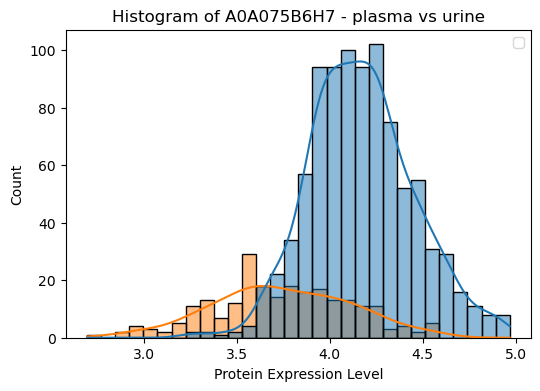

In [90]:
plt.figure(figsize=(6, 4))
sns.histplot(d_plot[d_plot['variable'] == 'A0A075B6H7'].reset_index(drop=True), x='value', hue='specimen', bins=30, kde=True)
plt.title('Histogram of A0A075B6H7 - plasma vs urine')
plt.xlabel('Protein Expression Level')
plt.ylabel('Count')
plt.legend([])
plt.show()

In [ ]:
# do the same for other proteins and or specific diseases

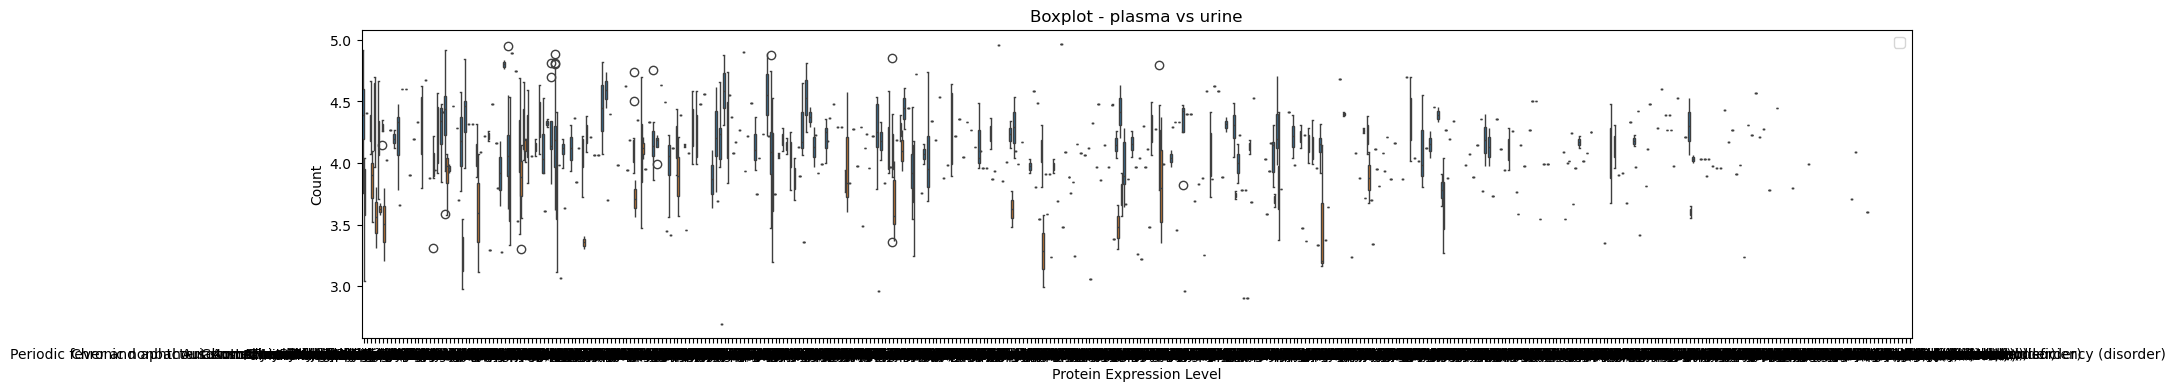

In [91]:
plt.figure(figsize=(20, 4))
sns.boxplot(d_plot[d_plot['variable'] == 'A0A075B6H7'].reset_index(drop=True), y='value', x='sct_description', hue='specimen')
plt.title('Boxplot - plasma vs urine')
plt.xlabel('Protein Expression Level')
plt.ylabel('Count')
plt.legend([])
plt.show()

In [92]:
top_conditions = d_plot['sct_description'].value_counts()[d_plot['sct_description'].value_counts() > 100].index

In [93]:
d_plot['variable'].value_counts()

variable
A0A075B6H7    2125
A0A075B6I0    2125
A0A075B6I9    2125
A0A075B6J9    2125
A0A075B6K4    2125
A0A075B6K5    2125
Name: count, dtype: int64

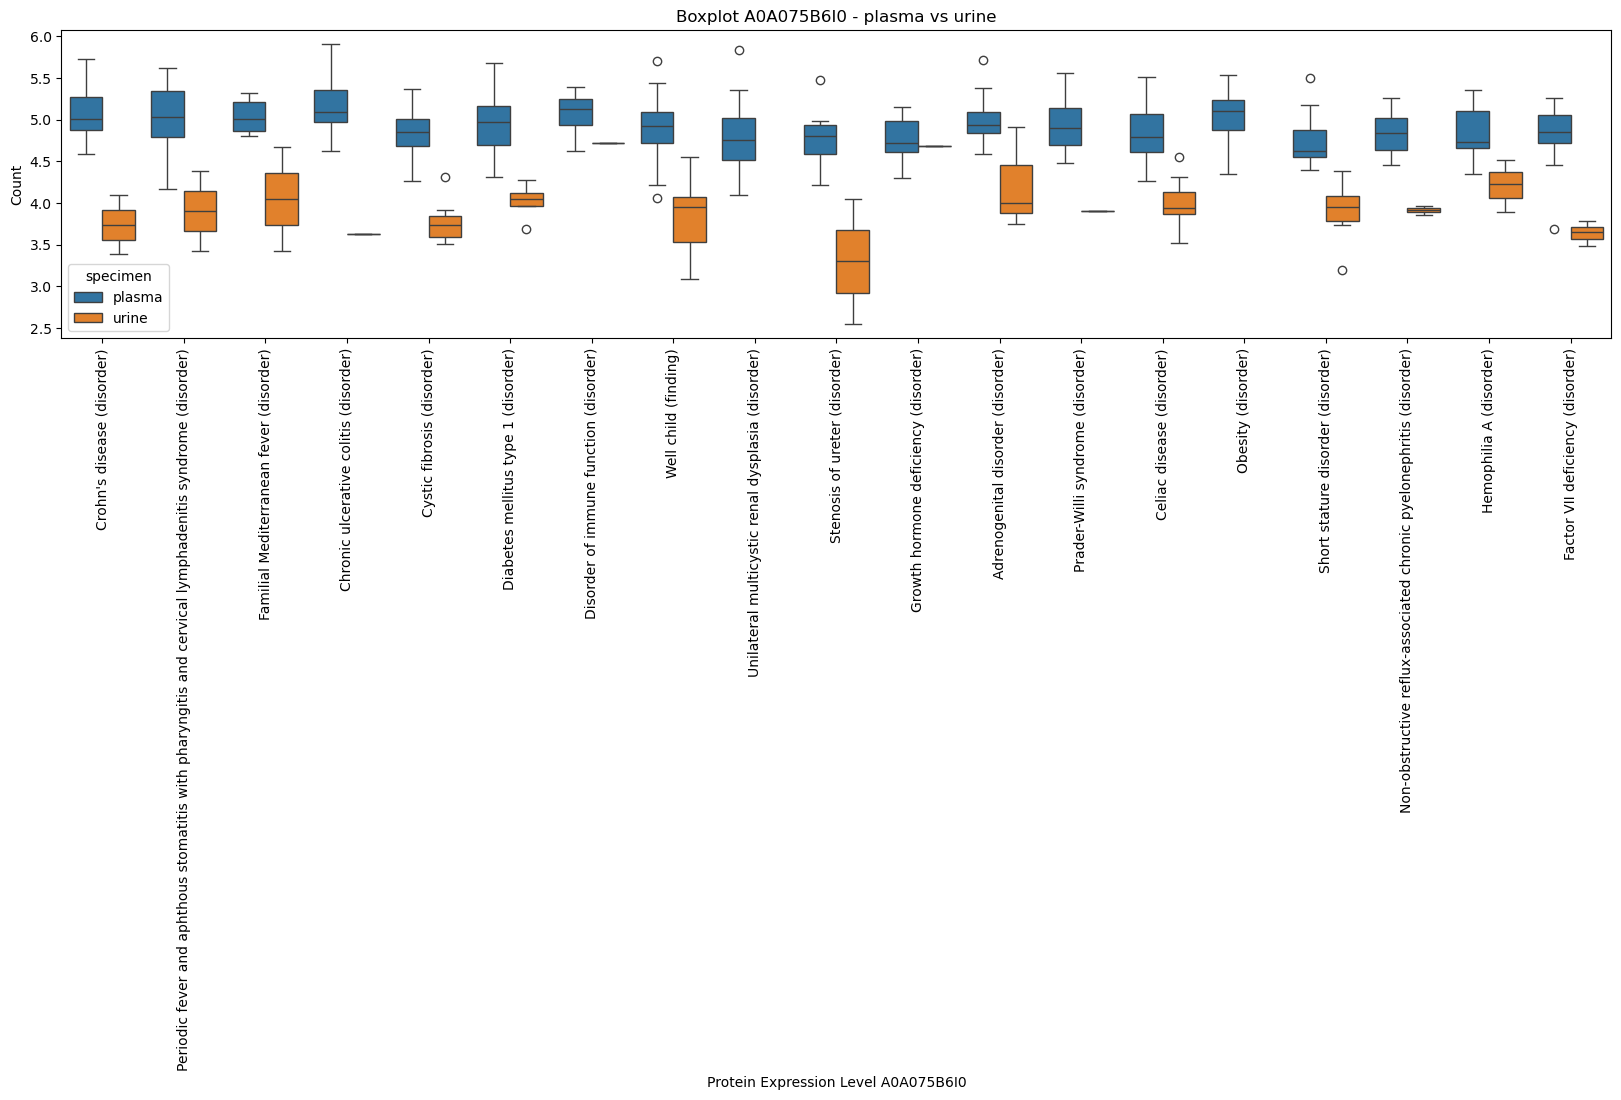

In [95]:
protein = 'A0A075B6I0'

plt.figure(figsize=(20, 4))
sns.boxplot(d_plot[(d_plot['variable'] == protein) & (d_plot['sct_description'].isin(top_conditions))].reset_index(drop=True), 
            y='value', x='sct_description', hue='specimen')
plt.title(f'Boxplot {protein} - plasma vs urine')
plt.xlabel(f'Protein Expression Level {protein}')
plt.ylabel('Count')
plt.xticks(rotation=90)
plt.show()